# EvidenceLab #04
## CFR vs IFR: When the Denominator Changes the Story
**A 5% CFR does not mean 5% of everyone infected will die.**

Dr. Amobi Andrew Onovo · See it. Understand it. Run it.

### No setup required
✓ No dataset to download  
✓ No file paths to enter  
✓ No coding experience required  
✓ All teaching data are generated automatically  
✓ Runs directly in Google Colab's standard Python runtime

Select **Runtime → Run all**, then read from top to bottom. The notebook creates the data,
performs the calculations, draws the charts and exports the results. No uploads, API keys or prompts.

By the end you will understand:

**CFR = deaths among detected cases ÷ detected cases**  
**IFR = deaths among everyone infected ÷ estimated total infections**

**The denominator must match the question.** All individual records are synthetic teaching data.
The published study is a separate historical example, not a replication.

### Your learning route
**START** → 1 · Meet the outbreak → 2 · Calculate CFR → 3 · Reveal missing infections →
4 · Calculate IFR → 5 · Estimate infections from survey data → 6 · Quantify uncertainty →
7 · Stress-test assumptions → 8 · Connect to the published African COVID-19 study →
9 · Try it yourself → **FINISH**

## 1–2 | Meet the outbreak and calculate CFR
Imagine a **completed, closed infection cohort** with 1,000 detected cases and 50 attributable deaths.
All fatal infections were detected and follow-up is complete. We start with the completed cohort
to isolate the denominator effect; later we return to what was actually knowable at outbreak onset.

This cell calculates fatality among detected cases. Look for **who is counted in the denominator**.

In [1]:
deaths = 50
detected_cases = 1000
cfr = deaths / detected_cases
print(f"CFR = {deaths} deaths ÷ {detected_cases:,} detected cases = {cfr:.1%}")

CFR = 50 deaths ÷ 1,000 detected cases = 5.0%


Among the people detected as cases, **5% died**. This does not mean that 5% of everyone
infected died: mild or asymptomatic infections may never have entered surveillance.

## 3–4 | Reveal missing infections and calculate IFR
Suppose independent evidence estimates **10,000 total infections** in the same cohort.
Keep the same 50 deaths. Look for how changing the denominator changes the interpretation.

In [2]:
estimated_infections = 10000
ifr = deaths / estimated_infections
print(f"IFR = {deaths} deaths ÷ {estimated_infections:,} estimated infections = {ifr:.1%}")

IFR = 50 deaths ÷ 10,000 estimated infections = 0.5%


Among everyone estimated to have been infected, **0.5% died**.

**Same 50 deaths. Different denominator. Different interpretation.**
These are different questions, not rival measurements of one quantity.

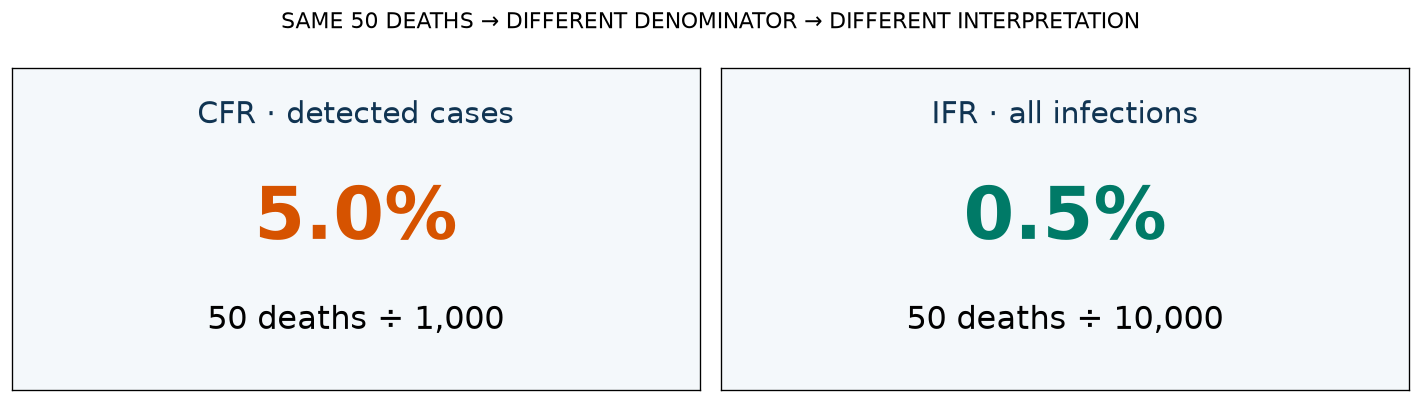

In [3]:
import matplotlib.pyplot as plt
from IPython.display import display, SVG
plt.rcParams.update({'font.size': 12, 'figure.dpi': 120})
fig, axes = plt.subplots(1, 2, figsize=(12, 3.4))
for ax, title, denominator, value, color in zip(
    axes, ['CFR · detected cases', 'IFR · all infections'],
    [1000, 10000], [cfr, ifr], ['#d65300', '#007a67']):
    ax.set_facecolor('#f4f8fb')
    ax.text(.5, .83, title, ha='center', fontsize=18, color='#103452', transform=ax.transAxes)
    ax.text(.5, .47, f'{value:.1%}', ha='center', fontsize=44, weight='bold', color=color, transform=ax.transAxes)
    ax.text(.5, .19, f'50 deaths ÷ {denominator:,}', ha='center', fontsize=19, transform=ax.transAxes)
    ax.set_xticks([]); ax.set_yticks([])
fig.suptitle('SAME 50 DEATHS → DIFFERENT DENOMINATOR → DIFFERENT INTERPRETATION', fontsize=13)
fig.tight_layout()
plt.show()

## 5 | But where did 10,000 infections come from?
CFR is relatively easy to calculate because detected cases and reported deaths are often
available from surveillance. IFR requires evidence about infections surveillance missed.
A representative infection survey or an externally calibrated ascertainment model can help.
Case and death totals alone cannot reveal this hidden denominator.

We now build the data behind the example. Look for the evidence and assumptions needed
to connect surveillance, the survey and follow-up to the same population and period.

## What outbreak onset means here
There is no universal 14-day or 30-day definition. Here it means the initial recognition and
expansion phase, when ascertainment is changing and many infections have not had enough
follow-up for fatal outcomes to occur and be reported. Its duration depends on the pathogen,
transmission, surveillance and outcome delay. Our day-21 snapshot is an illustration, not a
clinical threshold. A later survey cannot be used as if it had been available on day 21.

CFR = disease-attributable deaths among detected cases / detected cases.
IFR = disease-attributable deaths among all infected people / all infected people.
They are proportions (often called “rates”), not deaths per person-time. Neither is a fixed
measure of a pathogen's “killing power”: population age, immunity, care and period matter.

An IFR is not automatically more reliable at onset: its infection denominator and death
timing may be especially uncertain then. A qualified CFR is useful for detected-case outcomes;
a defensible IFR answers a broader population question.

In [4]:
import sys, json, platform
from pathlib import Path
import numpy as np
import pandas as pd
SEED = 20260925
rng = np.random.default_rng(SEED)
out = Path('evidencelab04_outputs')
out.mkdir(exist_ok=True)
print({'Python':sys.version.split()[0], 'numpy':np.__version__, 'pandas':pd.__version__, 'seed':SEED})

{'Python': '3.12.14', 'numpy': '2.5.3', 'pandas': '3.0.6', 'seed': 20260925}


### Features and evidence required before estimating IFR

| Input | Required fields or evidence | Purpose |
|---|---|---|
| Case line list | unique ID, case definition, geography, onset/diagnosis date, extract date | define detected cases and avoid duplicates |
| Outcomes | attributable death flag and date, follow-up date, pending/recovered/dead status | align numerator and follow-up; pending is not survival |
| Infection denominator | representative infection survey with sampling date, result, sampling frame and selection probabilities, **or** externally calibrated ascertainment model | estimate infections missed by case surveillance |
| Population | population size, geography, reference period, age strata | expand prevalence and assess population comparability |
| Test validation | sensitivity, specificity, validation counts/uncertainty, antibody timing/waning, prior infection and vaccination history as relevant | distinguish assay positivity from infection |
| Delay evidence | infection-to-detection/death/reporting distributions or linked completed cohort | account for right censoring and reporting delays |
| Mortality surveillance | death ascertainment completeness and attribution rules | assess missed deaths, including outside facilities |

Useful model covariates include age, comorbidity, testing access and healthcare capacity.
**Adding these to regression does not by itself identify undetected infections.** Testing
volume is not equivalent to detection probability. If no defensible infection denominator
exists, report a qualified CFR and evidence gaps; do not manufacture an IFR.

The survey below is a deliberately simple equal-probability sample. Real complex surveys
need design weights, clustering/nonresponse adjustment and age-specific analysis. The
synthetic scenario has no earlier infections, no vaccination and no transmission after
day 14; these strong assumptions make cohort alignment transparent.

### CHECK → CLEAN → VERIFY → ANALYZE
We generate a deliberately untidy case register, then remove exact duplicates, standardize
categories, check dates and verify outcomes. **A missing outcome is never silently treated as survival.**
Look for one duplicate and one impossible diagnosis date; the verified cases remain in the analysis.

In [5]:
# A closed infection cohort acquired infection on days 0–14 in a population of 100,000.
# Surveillance detects 1,000 cases. Fifty attributable deaths ultimately occur, all detected.
# We construct an exact teaching example rather than randomizing its headline totals.
population = 100_000
base = pd.Timestamp('2026-01-01')
snapshot = base + pd.Timedelta(days=21)
final_date = base + pd.Timedelta(days=56)
case = pd.DataFrame({'case_id':[f'C{i:04}' for i in range(1000)],
    'region':'Example district', 'case_definition':'laboratory confirmed',
    'onset_date':base + pd.to_timedelta(np.arange(1000)%15, unit='D')})
case['diagnosis_date'] = case.onset_date + pd.Timedelta(days=2)
case['outcome'] = ['dead']*50 + ['recovered']*950
case['outcome_date'] = base + pd.to_timedelta(
    np.r_[np.full(30,20),np.full(20,35),np.full(950,28)],unit='D')
case['last_followup_date'] = final_date
# Dirty export: duplicate, whitespace/case differences, missing date and impossible date.
raw = case.astype(str)
raw.loc[7,'outcome']=' DEAD '
raw.loc[55,'region']=' Example district '
raw.loc[900,'onset_date']='unknown'
raw.loc[901,'diagnosis_date']='2025-12-01'
raw = pd.concat([raw,raw.iloc[[0]]],ignore_index=True)
raw.to_csv(out/'synthetic_cases_raw.csv',index=False)
print('Raw rows:',len(raw))

Raw rows: 1001


### Under the hood: reusable data-quality checks
Drop exact duplicate records only. Conflicting duplicate IDs should stop the pipeline for
review. Quarantine impossible dates without deleting otherwise verified cases or deaths.
Do not impute “recovered” for missing outcomes, or zero for missing death counts.
For this lesson the closed cohort's membership is known independently; in real data,
missing onset dates can make cohort eligibility uncertain and require sensitivity analysis.

The next function implements these checks and writes an audit trail. You can follow the
printed audit without needing to understand every line of the reusable function.

In [6]:
def clean_cases(raw):
    x=raw.copy()
    for col in ['case_id','region','case_definition','outcome']:
        x[col]=x[col].astype('string').str.strip()
    x['outcome']=x.outcome.str.lower()
    before=len(x); x=x.drop_duplicates().copy()
    if x.case_id.isna().any() or x.case_id.eq('').any():
        raise ValueError('Missing case ID')
    if x.case_id.duplicated().any():
        raise ValueError('Conflicting duplicate case IDs require review')
    if not x.outcome.isin(['dead','recovered','pending']).all():
        raise ValueError('Unknown outcome category')
    for col in ['onset_date','diagnosis_date','outcome_date','last_followup_date']:
        x[col]=pd.to_datetime(x[col],errors='coerce')
    bad=(x.diagnosis_date<x.onset_date)
    x.loc[bad,'diagnosis_date']=pd.NaT
    if (x.outcome_date>x.last_followup_date).any():
        raise ValueError('Outcome is after follow-up date')
    if (x.outcome_date<x.onset_date).any():
        raise ValueError('Outcome precedes onset')
    if x.loc[x.outcome.eq('dead'),'outcome_date'].isna().any():
        raise ValueError('Death date missing: resolve before temporal analysis')
    audit={'exact_duplicates_removed':before-len(x),
           'invalid_diagnosis_dates_quarantined':int(bad.sum()),
           'missing_onset_dates':int(x.onset_date.isna().sum()),
           'retained_cases':len(x)}
    return x,audit
clean,audit=clean_cases(raw)
print(audit)
clean.to_csv(out/'synthetic_cases_clean.csv',index=False)
(out/'cleaning_audit.json').write_text(json.dumps(audit,indent=2))
assert len(clean)==1000 and clean.outcome.eq('dead').sum()==50
# Meaningful failure-path checks: a conflicting identity must not be silently accepted.
conflict=raw.iloc[[1]].copy(); conflict['region']='Different district'
try:
    clean_cases(pd.concat([raw,conflict],ignore_index=True))
    raise AssertionError('Conflicting IDs should fail')
except ValueError as e:
    assert 'Conflicting' in str(e)

{'exact_duplicates_removed': 1, 'invalid_diagnosis_dates_quarantined': 1, 'missing_onset_dates': 1, 'retained_cases': 1000}


The cleaned register retains **1,000 cases and 50 eventual deaths**. One exact duplicate
was removed, one impossible diagnosis date was quarantined, and one onset date remains missing.
The conflict check also confirms that inconsistent records sharing an ID stop the analysis.

### Return to outbreak onset: what is known on day 21?
We compare an early snapshot with completed follow-up. Look for outcomes that have not
yet occurred or been reported; the complete future record is available only for teaching.

The synthetic surveillance register independently confirms all 1,000 cases were registered
by day 21. Thirty deaths are known then; 970 case outcomes remain unresolved. The analyst
does **not** have the future outcome column on day 21. We use it only to demonstrate the
eventual bias. Dividing deaths by deaths plus recoveries is also misleading here: it gives
100% on day 21 because none of the recoveries have yet been recorded.

In [7]:
deaths_early=int((clean.outcome.eq('dead') & clean.outcome_date.le(snapshot)).sum())
deaths_final=int(clean.outcome.eq('dead').sum())
cases=len(clean)
early_cfr=deaths_early/cases
final_cfr=deaths_final/cases
resolved_early=int(clean.outcome_date.le(snapshot).sum())
print(f'Day 21 crude CFR: {deaths_early}/{cases} = {early_cfr:.1%}')
print(f'Pending outcomes: {cases-resolved_early}; resolved-only fraction: {deaths_early/resolved_early:.0%}')
print(f'After follow-up: {deaths_final}/{cases} = {final_cfr:.1%}')
assert deaths_early==30 and deaths_final==50

Day 21 crude CFR: 30/1000 = 3.0%
Pending outcomes: 970; resolved-only fraction: 100%
After follow-up: 50/1000 = 5.0%


**Day 21:** 30 deaths ÷ 1,000 detected cases = **3.0% crude CFR**, with 970 unresolved outcomes.
**After follow-up:** 50 deaths ÷ 1,000 detected cases = **5.0% CFR**.
The early 3% is not the completed-cohort risk. Restricting the denominator to resolved cases
also fails here: recovery and death are recorded on different schedules.

### Estimate infections from a representative survey
A test can miss infected people and occasionally classify uninfected people as positive.
Therefore, the percentage testing positive is not automatically the percentage infected.
We correct observed positivity using sensitivity (detecting true infections) and specificity
(correctly identifying uninfected people). Look for how **9.95% positivity becomes 10% estimated prevalence**.

At day 42 a representative survey tests 2,000 people; 199 test positive. Assume sensitivity
95% and specificity 99.5%, valid at that sampling time. The survey frame represents the
original 100,000-person cohort, including ascertainment of infection status for people who
died. This idealization avoids silently excluding fatal infections from the denominator.
A real survivor-only survey requires explicit correction for deaths and frame changes.

Observed positivity = sensitivity × prevalence + (1 − specificity) × (1 − prevalence).
Solving gives the Rogan–Gladen correction. Do not silently clip incompatible inputs into
0–1 and present them as a valid estimate. This survey identifies infections retrospectively;
it was unavailable during the early snapshot.

**Correction:** prevalence = (observed positivity + specificity − 1) ÷ (sensitivity + specificity − 1).
This removes expected false positives and accounts for imperfect detection.

**Worked example:** (0.0995 + 0.995 − 1) ÷ (0.95 + 0.995 − 1) = 0.10.
Estimated infections = 100,000 people × 0.10 = **10,000 infections**.

In [8]:
survey=pd.DataFrame({'participant_id':[f'S{i:04}' for i in range(2000)],
    'region':'Example district','sample_date':base+pd.Timedelta(days=42),
    'test_positive':np.r_[np.ones(199,dtype=int),np.zeros(1801,dtype=int)],
    'sampling_weight':np.full(2000,50.0)})
survey.to_csv(out/'synthetic_survey.csv',index=False)
def estimate_prevalence(k,n,se,sp):
    if not (n>0 and 0<=k<=n and 0<se<=1 and 0<sp<=1 and se+sp>1):
        raise ValueError('Invalid sample or non-informative assay')
    p=(k/n+sp-1)/(se+sp-1)
    if not 0<p<=1:
        raise ValueError('Incompatible or zero prevalence: fit a measurement model')
    return p
n=len(survey); k=int(survey.test_positive.sum()); se=.95; sp=.995
p_hat=estimate_prevalence(k,n,se,sp)
infections=population*p_hat
ifr=deaths_final/infections
print(f'Observed positivity: {k}/{n} = {k/n:.2%}')
print(f'Assay-adjusted prevalence: {p_hat:.2%}; estimated infections: {infections:,.0f}')
print(f'CFR = {deaths_final} deaths ÷ {cases:,} detected cases = {final_cfr:.1%}')
print(f'IFR = {deaths_final} deaths ÷ {infections:,.0f} estimated infections = {ifr:.1%}')
assert np.isclose(infections,10000) and np.isclose(ifr,.005)

Observed positivity: 199/2000 = 9.95%
Assay-adjusted prevalence: 10.00%; estimated infections: 10,000
CFR = 50 deaths ÷ 1,000 detected cases = 5.0%
IFR = 50 deaths ÷ 10,000 estimated infections = 0.5%


The survey now supplies evidence for the denominator we initially assumed:
**CFR = 50 ÷ 1,000 = 5.0%** and **IFR = 50 ÷ 10,000 = 0.5%**.
Both refer to the completed cohort. The day-42 survey was not available on day 21.

## 6 | Go deeper: How uncertain is our IFR estimate?
We estimated the infection denominator rather than observing it perfectly. Our IFR therefore
needs uncertainty. Follow **prior → observed survey data → posterior → infections → IFR**.
Look for an interval around 0.5%, not false precision in a single percentage.

### Technical note

Use a uniform Beta(1,1) prior for prevalence and the binomial likelihood for observed test
positivity. The grid is a numerical approximation to this one-parameter posterior, **not
MCMC**. Draw prevalence, transform each draw to infections, then divide deaths by each
draw: do not invert interval endpoints in the wrong order.

The interval below includes survey sampling uncertainty only. It conditions on fixed
sensitivity, specificity, population and 50 completely ascertained deaths. It excludes
death under-reporting, assay validation uncertainty, survey selection bias, antibody waning
and changing infection timing. It is not a complete uncertainty interval for a real outbreak.

In [9]:
def posterior_prevalence(k,n,se,sp,draws=50000):
    grid=np.linspace(.00001,.99999,50000)
    positivity=se*grid+(1-sp)*(1-grid)
    log_w=k*np.log(positivity)+(n-k)*np.log1p(-positivity)
    w=np.exp(log_w-log_w.max()); w/=w.sum()
    return rng.choice(grid,size=draws,p=w)
p_draw=posterior_prevalence(k,n,se,sp)
ifr_draw=deaths_final/(population*p_draw)
ifr_q=np.quantile(ifr_draw,[.025,.5,.975])
print('IFR posterior 2.5%, 50%, 97.5%:',[f'{x:.3%}' for x in ifr_q])
assert ifr_q[0]<ifr<ifr_q[2]

IFR posterior 2.5%, 50%, 97.5%: ['0.436%', '0.499%', '0.575%']


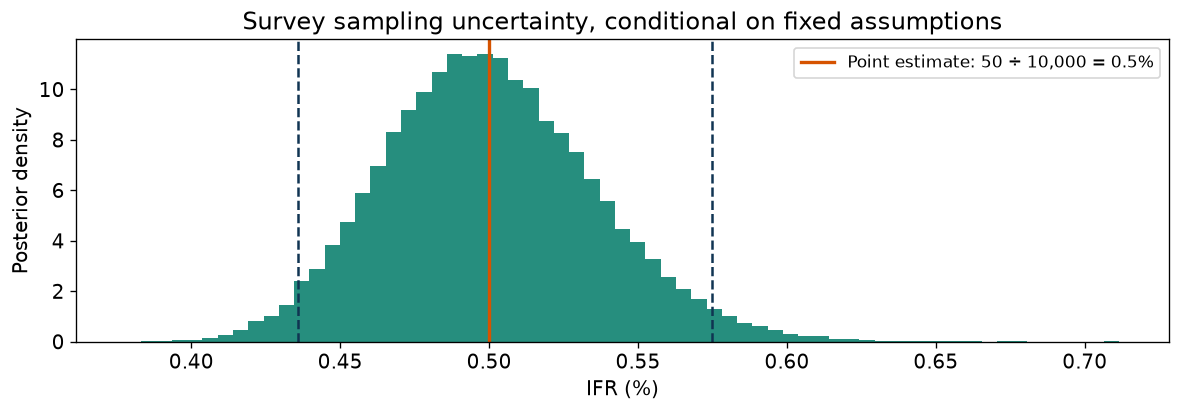

In [10]:
fig, ax = plt.subplots(figsize=(10, 3.6))
ax.hist(100*ifr_draw, bins=65, color='#007a67', alpha=.85, density=True)
ax.axvline(100*ifr, color='#d65300', linewidth=2, label='Point estimate: 50 ÷ 10,000 = 0.5%')
for endpoint in 100*ifr_q[[0, 2]]:
    ax.axvline(endpoint, color='#103452', linestyle='--')
ax.set(xlabel='IFR (%)', ylabel='Posterior density', title='Survey sampling uncertainty, conditional on fixed assumptions')
ax.legend(fontsize=10); fig.tight_layout()
fig.savefig(out/'ifr_uncertainty.png', dpi=180)
plt.show()

The 95% credible interval is approximately **0.436%–0.575%**, conditional on this prior,
sampling model, assay performance and complete death ascertainment. More infections imply a
smaller IFR for a fixed death count. This interval does not include every source of real-world uncertainty.

## 7 | Stress-test the conclusion
What if deaths were missed or assay performance differed? We recalculate under explicit assumptions.
Look for the direction and size of changes; these scenarios are not posterior probabilities.

Two mechanisms can act in opposite directions: missing mild infections can make a CFR
overstate risk among all infections; unresolved outcomes or missed deaths can lower crude
fatality estimates. The net direction is not guaranteed.

Here q_death is the assumed fraction of attributable deaths recorded; f_outcome is the
assumed fraction of eventual fatal outcomes already observed. IFR = D_observed /
(q_death × f_outcome × infections). In actual work f_outcome must come from a delay model
aligned with infection incidence, not a convenient guessed lag. The day-21 correction of
60% is known only because this is a simulation: do not use future information in forecasting.

**Worked example:** with 80% death ascertainment and complete follow-up,
50 ÷ (0.8 × 1 × 10,000) = **0.625% IFR**, implying 62.5 expected deaths after adjustment.
The fractional count is a model expectation, not a claim about half a person.

In [11]:
rows=[]
for q_death in [1.,.8,.6]:
    for sensitivity,specificity in [(.95,.995),(.90,.995),(.95,.99)]:
        p=estimate_prevalence(k,n,sensitivity,specificity)
        rows.append({'death_completeness':q_death,'sensitivity':sensitivity,
          'specificity':specificity,'IFR_percent':100*deaths_final/q_death/(population*p)})
sensitivity_table=pd.DataFrame(rows)
print(sensitivity_table.round(3).to_string(index=False))
sensitivity_table.to_csv(out/'sensitivity.csv',index=False)
print(f'Early deaths / later estimated infections = {deaths_early/infections:.1%} (temporally incomplete)')
print(f'Synthetic delay-corrected result = {deaths_early/(.6*infections):.1%}')

 death_completeness  sensitivity  specificity  IFR_percent
                1.0         0.95        0.995        0.500
                1.0         0.90        0.995        0.474
                1.0         0.95        0.990        0.525
                0.8         0.95        0.995        0.625
                0.8         0.90        0.995        0.592
                0.8         0.95        0.990        0.656
                0.6         0.95        0.995        0.833
                0.6         0.90        0.995        0.789
                0.6         0.95        0.990        0.875
Early deaths / later estimated infections = 0.3% (temporally incomplete)
Synthetic delay-corrected result = 0.5%


Missed deaths increase the adjusted IFR. Assay changes alter the infection denominator.
Combining day-21 deaths with a later infection estimate yields **30 ÷ 10,000 = 0.3%**,
which is temporally incomplete. The simulated 60% outcome correction recovers **0.5%**;
in a real outbreak that fraction needs independent delay evidence.

### When no survey is available
We examine externally supplied detection probabilities. Look for how several infection totals
can fit the same case count: observed cases alone do not choose between them.

An externally validated ascertainment model can provide p_detect, the fraction of infections
detected. Then infections ≈ cases / p_detect and IFR ≈ deaths × p_detect / cases after
outcome and death-ascertainment adjustment. This is a **conditional scenario**, not an IFR
identified by case and death totals alone. Different p_detect values fit the same observed
case count with different total infections. Do not derive p_detect from an assumed IFR
and then claim to have independently estimated that same IFR.

**Worked example:** if detection probability is independently estimated as 0.10,
1,000 ÷ 0.10 = 10,000 infections and 50 × 0.10 ÷ 1,000 = **0.5% conditional IFR**.

In [12]:
alternative=pd.DataFrame({'p_detect':[.05,.10,.20]})
alternative['estimated_infections']=cases/alternative.p_detect
alternative['conditional_IFR_percent']=100*deaths_final/alternative.estimated_infections
print(alternative.to_string(index=False))
alternative.to_csv(out/'ascertainment_scenarios.csv',index=False)

 p_detect  estimated_infections  conditional_IFR_percent
     0.05               20000.0                     0.25
     0.10               10000.0                     0.50
     0.20                5000.0                     1.00


The assumed detection probability changes the inferred IFR. Without evidence for that
probability, these are scenarios, not identified infection-fatality estimates.

### What happens when surveillance improves?
Now hold the **true closed cohort** fixed at 10,000 infections and 50 deaths, all detected.
Only the number of detected nonfatal infections changes. Unlike the preceding table,
this experiment holds infections fixed and varies observed cases.

Look for CFR approaching IFR as detection becomes complete. The table and chart run automatically;
the optional slider lets you inspect additional detection counts.

,detected_cases,CFR_percent,IFR_percent
0,1000,5.0,0.5
1,2000,2.5,0.5
2,5000,1.0,0.5
3,10000,0.5,0.5


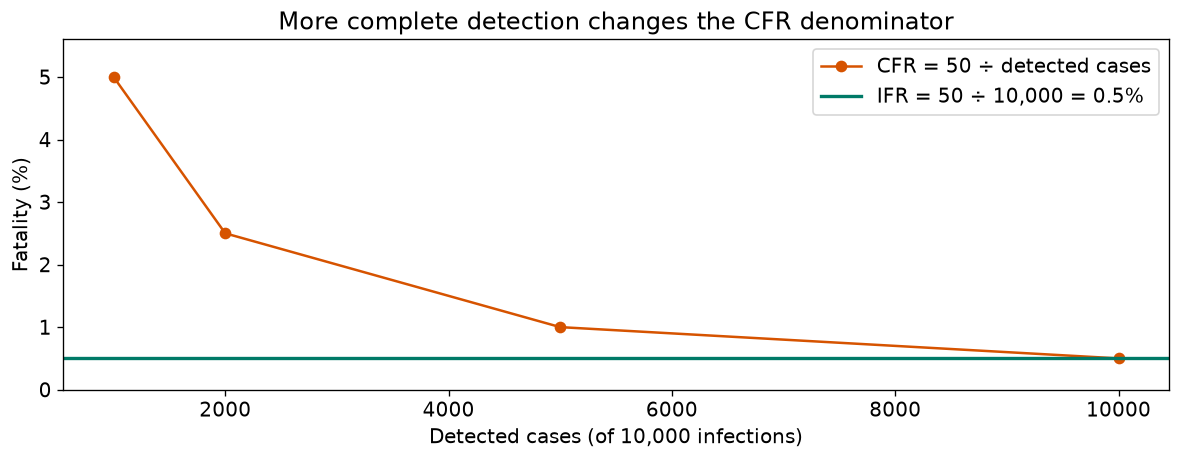

In [13]:
experiment = pd.DataFrame({'detected_cases': [1000, 2000, 5000, 10000]})
experiment['CFR_percent'] = 100*50/experiment.detected_cases
experiment['IFR_percent'] = 100*50/10000
display(experiment)
experiment.to_csv(out/'surveillance_experiment.csv', index=False)
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(experiment.detected_cases, experiment.CFR_percent, 'o-', color='#d65300', label='CFR = 50 ÷ detected cases')
ax.axhline(.5, color='#007a67', linewidth=2, label='IFR = 50 ÷ 10,000 = 0.5%')
ax.set(xlabel='Detected cases (of 10,000 infections)', ylabel='Fatality (%)', title='More complete detection changes the CFR denominator')
ax.set_ylim(0, 5.6); ax.legend(); fig.tight_layout()
fig.savefig(out/'surveillance_experiment.png', dpi=180)
plt.show()
assert experiment.CFR_percent.tolist() == [5., 2.5, 1., .5]
assert experiment.IFR_percent.eq(.5).all()

In [14]:
# Optional interaction: the complete static analysis above requires no widget support.
try:
    import ipywidgets as widgets
except ImportError:
    print('Interactive controls are unavailable; the complete table and chart above remain usable.')
else:
    slider = widgets.IntSlider(value=1000, min=1000, max=10000, step=100,
                               description='Detected:', continuous_update=False)
    readout = widgets.HTML()
    def update_readout(change=None):
        count = slider.value
        readout.value = (f'<b>CFR = 50 deaths ÷ {count:,} detected cases = {50/count:.2%}</b><br>'
                         '<b>IFR = 50 deaths ÷ 10,000 infections = 0.50%</b>')
    slider.observe(update_readout, names='value')
    update_readout()
    display(widgets.VBox([slider, readout]))

CFR falls from **5.0% to 0.5%** while IFR stays **0.5%** in this controlled example.
Real outbreaks also involve changing risk, case definitions, death detection and outcome/reporting
delays. Improved surveillance alone does not guarantee this exact trajectory.

## 8 | Real-world evidence: COVID-19 across 48 African countries
**Published model-based example — not the synthetic survey analysis.**

- Confirmed cases: **135,126**
- Reported deaths: **3,922**
- Model-estimated infections: **1,686,879 (approximately 1.69 million)**

We calculate the two percentages from the paper's aggregate totals. Look for the same reported
deaths in both numerators and the substantially larger modeled infection denominator.

In [15]:
paper={'reported_cases':135126,'reported_deaths':3922,'modeled_infections':1686879}
paper['arithmetic_CFR_percent']=100*paper['reported_deaths']/paper['reported_cases']
paper['arithmetic_IFR_percent']=100*paper['reported_deaths']/paper['modeled_infections']
paper['infections_per_reported_case']=paper['modeled_infections']/paper['reported_cases']
print(json.dumps(paper,indent=2))

{
  "reported_cases": 135126,
  "reported_deaths": 3922,
  "modeled_infections": 1686879,
  "arithmetic_CFR_percent": 2.9024762073916195,
  "arithmetic_IFR_percent": 0.23250037495279743,
  "infections_per_reported_case": 12.483748501398695
}


In [16]:
print(f"Crude CFR = {paper['reported_deaths']:,} deaths ÷ {paper['reported_cases']:,} cases = {paper['arithmetic_CFR_percent']:.2f}%")
print(f"Model-based IFR = {paper['reported_deaths']:,} deaths ÷ {paper['modeled_infections']:,} modeled infections = {paper['arithmetic_IFR_percent']:.2f}%")

Crude CFR = 3,922 deaths ÷ 135,126 cases = 2.90%
Model-based IFR = 3,922 deaths ÷ 1,686,879 modeled infections = 0.23%


**The reported deaths did not change. The estimated denominator did.**
These arithmetic results describe the published historical assumptions; they do not validate
the infection denominator independently.

### Go deeper: How did the original study estimate infections?

[Onovo et al., BioMed (2021)](https://doi.org/10.3390/biomed1010005)
was published on 13 September 2021 and analyzed data through 30 May 2020. It reported
135,126 cases, 3,922 deaths and 1,686,879 modeled infections, with an IFR of 0.23%
(reported 95% interval 0.14–0.33%). Those are historical model estimates, not current risks.

The model used Bayesian normal regression with Gibbs sampling and country covariates:
population density, age 65+, cardiovascular mortality, diabetes, handwashing access and
extreme poverty. The paper collected transmission-classification information too. Its
central denominator assumption used an upper 95% predictive bound as a proxy for infections.
Six countries reporting no deaths were excluded. These choices deserve sensitivity analysis.
Reported-death completeness and outcome delay remain concerns; covariate prediction alone
does not establish the unobserved infection count. The published interval is reproduced as
reported, not relabeled as the interval from this notebook.

The notebook intentionally uses independent survey evidence rather than presenting the
upper-bound proxy as a generally validated estimator. Full replication would require the
original frozen inputs, priors, implementation choices and executable code. The reusable
lesson is explicit denominators, assumptions, uncertainty and validation.

## 9 | Choose the measure, then try it yourself
Use the decision aid to match the question to the evidence. Look for both the denominator
and whether the outcomes have had enough time to occur.

| Question | Report | Qualification |
|---|---|---|
| How many detected cases have died so far? | crude CFR | date, case definition, pending outcomes, surveillance changes |
| Fatality among a detected cohort? | completed-cohort or delay-adjusted CFR | follow-up, attribution and selection |
| Fatality among everyone infected? | IFR estimate | defensible infection denominator, matched deaths and uncertainty |
| Infection denominator unavailable? | qualified CFR and data gaps | do not relabel CFR or fabricate an IFR |

Suggested teaching result: “Among 1,000 detected cases, 50 deaths occurred after follow-up:
CFR 5%. A representative, assay-adjusted survey estimated 10,000 infections in the same
closed cohort: estimated IFR 0.5%, conditional on complete death ascertainment.”

For Ebola disease, including Bundibugyo virus, transfer the **workflow**, not SARS-CoV-2
parameters. Validate pathogen-specific serology, asymptomatic infection assumptions, timing,
case/death definitions, care and surveillance. CFR remains a legitimate operational metric.
The 0.5% synthetic example must never be presented as an Ebola IFR.

### Try it
1. Change death completeness from 100% to 80%. Explain the change in IFR.
2. Increase assay false positives. What happens to estimated infections and IFR?
3. Explain why a larger dataset of detected cases cannot alone identify detection probability.
4. Which quantities were unknowable on day 21? Identify information leakage in a retrospective analysis.
5. Design an age-stratified version. Compare using the same population age weights before comparing districts.

### Sources
- [WHO, Estimating mortality from COVID-19, 4 August 2020](https://www.who.int/publications/i/item/WHO-2019-nCoV-Sci-Brief-Mortality-2020.1)
- [Onovo et al. (2021), original study](https://www.mdpi.com/2673-8430/1/1/5)
- [Rogan and Gladen (1978), estimating prevalence from screening tests](https://doi.org/10.1093/oxfordjournals.aje.a112510)
- [WHO Ebola disease fact sheet](https://www.who.int/news-room/fact-sheets/detail/ebola-disease)

### Review the denominator and the clock together
The final common-scale chart compares the early crude CFR with the two completed-cohort
estimates. Look for **3%, 5% and 0.5%** and explain what changes between each pair.

Saved comparison.svg; 3%, 5% and 0.5% on one scale.


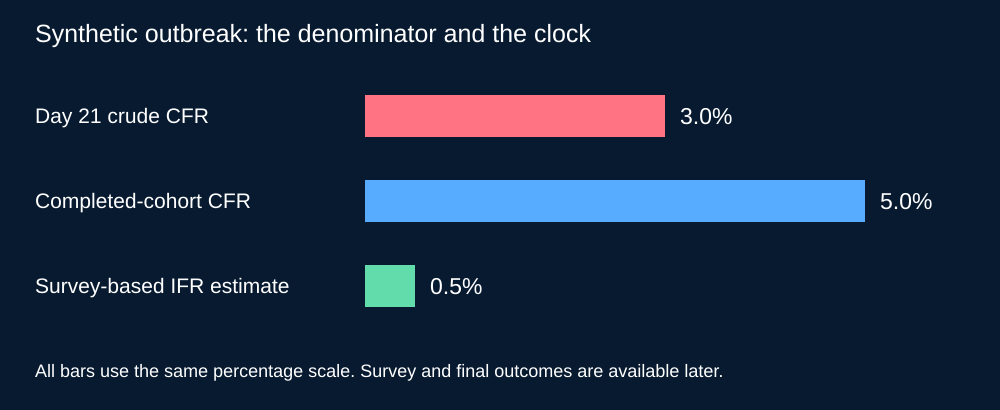

In [17]:
# A common-scale comparison, exported as SVG without extra plotting dependencies.
# The completed-cohort estimates are different quantities, not competing measurements.
bars=[('Day 21 crude CFR',100*early_cfr,'#FF7382'),
      ('Completed-cohort CFR',100*final_cfr,'#57ACFF'),
      ('Survey-based IFR estimate',100*ifr,'#63DCAC')]
parts=['<svg xmlns="http://www.w3.org/2000/svg" width="1000" height="410" viewBox="0 0 1000 410">',
       '<rect width="1000" height="410" fill="#071A30"/>',
       '<g font-family="Arial" fill="white">',
       '<text x="35" y="42" font-size="25">Synthetic outbreak: the denominator and the clock</text>']
for i,(label,value,color) in enumerate(bars):
    y=95+i*85
    parts += [f'<text x="35" y="{y+28}" font-size="21">{label}</text>',
        f'<rect x="365" y="{y}" width="{value/5*500}" height="42" fill="{color}"/>',
        f'<text x="{380+value/5*500}" y="{y+29}" font-size="23">{value:.1f}%</text>']
parts += ['<text x="35" y="377" font-size="18">All bars use the same percentage scale. Survey and final outcomes are available later.</text></g></svg>']
comparison_svg=''.join(parts)
(out/'comparison.svg').write_text(comparison_svg)
print('Saved comparison.svg; 3%, 5% and 0.5% on one scale.')
display(SVG(comparison_svg))

### Reproducible results you can keep
The notebook writes CSV data, the cleaning audit, scenario tables, charts and JSON summaries
to `evidencelab04_outputs` in the current runtime. Nothing needs to be uploaded or configured.
The Colab Files panel lets you download these automatically generated files if you want copies.

In [18]:
results={'synthetic':True,'seed':SEED,'cases':cases,'deaths_early':deaths_early,
  'deaths_final':deaths_final,'estimated_infections':infections,
  'CFR_early_percent':100*early_cfr,'CFR_final_percent':100*final_cfr,
  'IFR_percent':100*ifr,'IFR_conditional_posterior_percentiles':(100*ifr_q).tolist(),
  'assumptions':['closed infection cohort','representative equal-probability survey',
  'known assay performance','complete attributable death ascertainment','complete final follow-up']}
(out/'results.json').write_text(json.dumps(results,indent=2))
(out/'paper_arithmetic.json').write_text(json.dumps(paper,indent=2))
print('All checks passed. Outputs:', sorted(p.name for p in out.iterdir()))

All checks passed. Outputs: ['ascertainment_scenarios.csv', 'cleaning_audit.json', 'comparison.svg', 'ifr_uncertainty.png', 'paper_arithmetic.json', 'results.json', 'sensitivity.csv', 'surveillance_experiment.csv', 'surveillance_experiment.png', 'synthetic_cases_clean.csv', 'synthetic_cases_raw.csv', 'synthetic_survey.csv']


In [19]:
# Cross-check the headline results, time alignment and data-quality audit.
assert cases == 1000 and deaths_early == 30 and deaths_final == 50
assert np.isclose(final_cfr, .05) and np.isclose(ifr, .005)
assert np.isclose(infections, 10000)
assert audit['exact_duplicates_removed'] == 1
assert audit['invalid_diagnosis_dates_quarantined'] == 1
assert snapshot < survey.sample_date.min() < final_date
assert np.isclose(paper['arithmetic_CFR_percent'], 100*3922/135126)
assert np.isclose(paper['arithmetic_IFR_percent'], 100*3922/1686879)
print('Scientific and export checks passed.')

Scientific and export checks passed.


### Five takeaways
1. CFR and IFR answer different questions.
2. The denominator determines the interpretation.
3. IFR requires evidence about infections surveillance missed.
4. Timing and incomplete outcomes matter during active outbreaks.
5. Quantify uncertainty when the denominator is estimated.

## Before interpreting a fatality percentage, ask who entered the denominator.
**EvidenceLab | See it. Understand it. Run it.**